In [1]:
#Выгрузка датасета и информация
import pandas as pd

file_path = "Tetuan City power consumption.csv"
df = pd.read_csv(file_path)

print("--- Первые 5 строк датасета ---")
print(df.head())
print("\n" + "=" * 50 + "\n")

print("--- Общая информация о данных ---")
print(df.info())
print("\n" + "=" * 50 + "\n")

print(True, f"Размерность датасета (строк, колонок): {df.shape}")
print("\n" + "=" * 50 + "\n")

df["DateTime"] = pd.to_datetime(df["DateTime"])
df.set_index("DateTime", inplace=True)

print("--- Датасет после установки временного индекса ---")
print(df.head(2))

df.to_csv("Tetuan_City_cleaned.csv", index=True)

--- Первые 5 строк датасета ---
        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   
3  1/1/2017 0:30        6.121      75.0       0.083                  0.091   
4  1/1/2017 0:40        5.921      75.7       0.081                  0.048   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620                16128.87538   
1          0.085               29814.68354                19375.07599   
2          0.100               29128.10127                19006.68693   
3          0.096               28228.86076                18361.09422   
4          0.085               27335.69620                17872.34043   

   Zone 3  Power Consumption  
0                20240.96386 

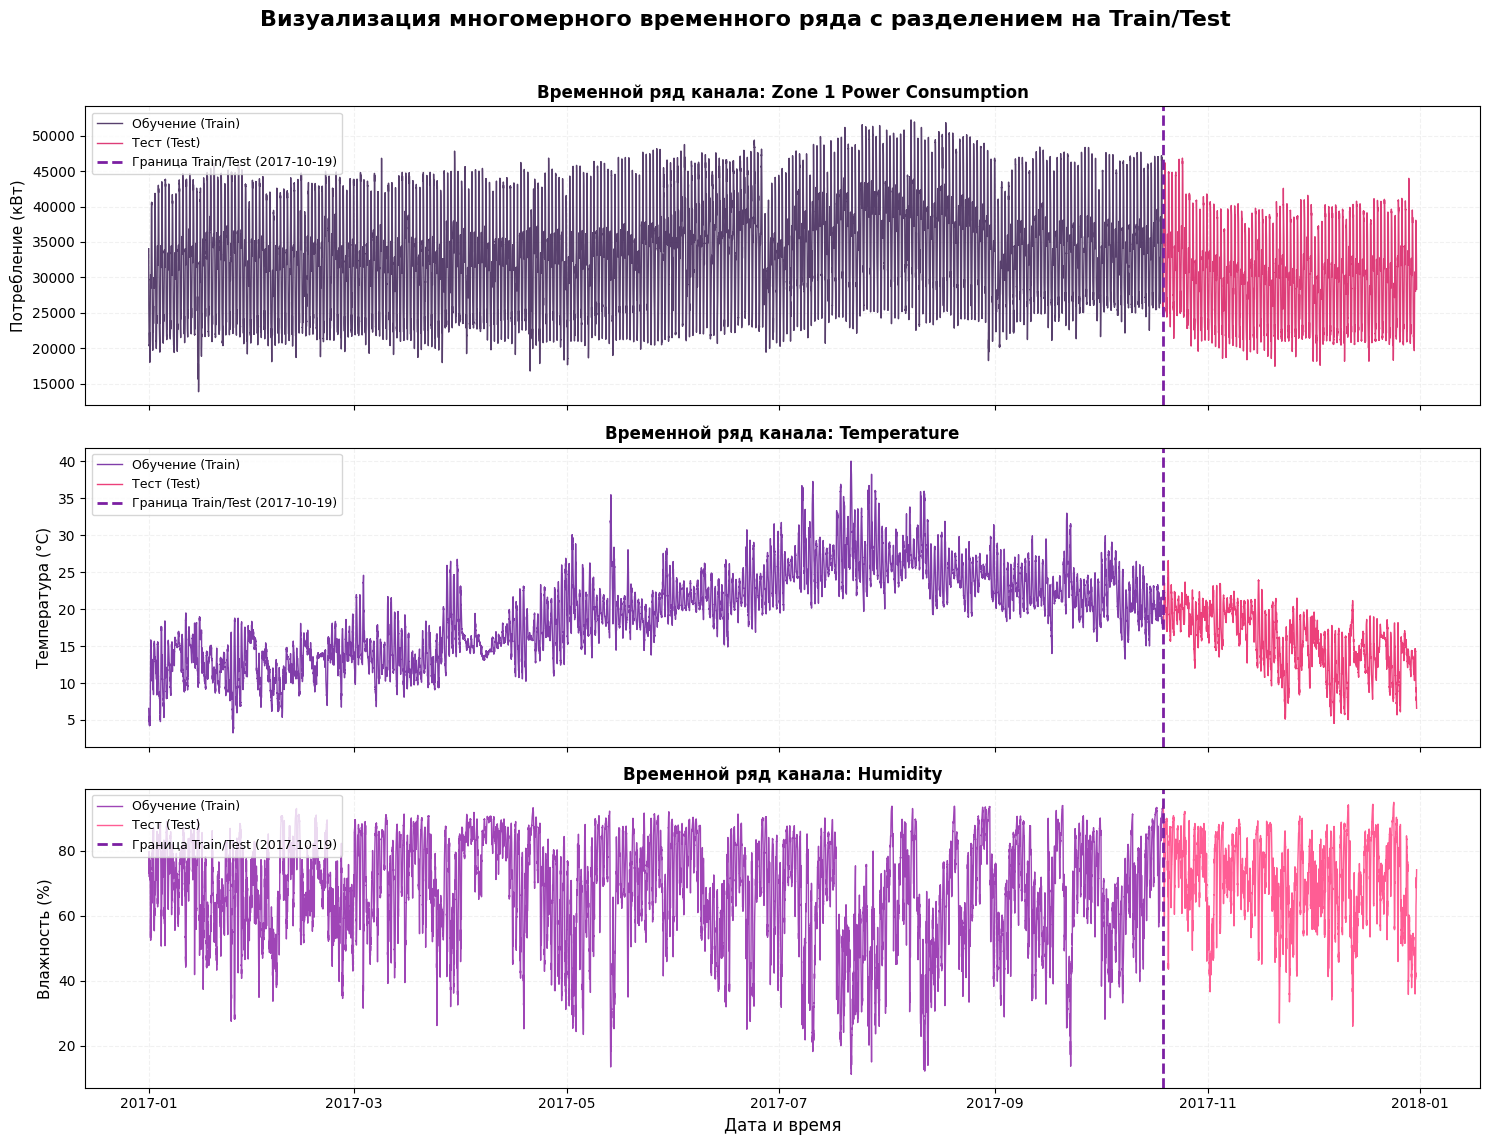

Граница разделения выборок: 2017-10-19 04:30:00


In [3]:
#Визуализация

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    "Tetuan_City_cleaned.csv", index_col="DateTime", parse_dates=True
)

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
split_date = train_df.index[-1]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 12), sharex=True)

channels = ["Zone 1 Power Consumption", "Temperature", "Humidity"]
y_labels = ["Потребление (кВт)", "Температура (°C)", "Влажность (%)"]

colors_train = ["#3B1E54", "#6A1B9A", "#8E24AA"]
colors_test = ["#D81B60", "#E91E63", "#FF4081"]
color_line = "#7B1FA2"

for i, channel in enumerate(channels):
    axes[i].plot(
        train_df.index,
        train_df[channel],
        label="Обучение (Train)",
        color=colors_train[i],
        alpha=0.85,
        linewidth=1,
    )
    axes[i].plot(
        test_df.index,
        test_df[channel],
        label="Тест (Test)",
        color=colors_test[i],
        alpha=0.85,
        linewidth=1,
    )
    axes[i].axvline(
        x=split_date,
        color=color_line,
        linestyle="--",
        linewidth=2,
        label=f'Граница Train/Test ({split_date.strftime("%Y-%m-%d")})',
    )

    axes[i].set_title(
        f"Временной ряд канала: {channel}", fontsize=12, fontweight="bold"
    )
    axes[i].set_ylabel(y_labels[i], fontsize=11)
    axes[i].grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")
    axes[i].legend(loc="upper left", fontsize=9)

plt.xlabel("Дата и время", fontsize=12)
plt.suptitle(
    "Визуализация многомерного временного ряда с разделением на Train/Test",
    fontsize=16,
    fontweight="bold",
    y=0.95,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print(f"Граница разделения выборок: {split_date}")

In [4]:
#Дискретность

import pandas as pd

df = pd.read_csv(
    "Tetuan_City_cleaned.csv", index_col="DateTime", parse_dates=True
)

stats_table = df.describe()
stats_table.rename(
    index={"25%": "Q1", "50%": "Q2 (Median)", "75%": "Q3"}, inplace=True
)

print("--- ТАБЛИЦА СТАТИСТИЧЕСКИХ ХАРАКТЕРИСТИК КАНАЛОВ ---")
print(stats_table.to_string())
print("\n" + "=" * 80 + "\n")

time_diffs = pd.Series(df.index).diff().dropna()
unique_intervals = time_diffs.value_counts()

print("--- АНАЛИЗ ЧАСТОТЫ ДИСКРЕТИЗАЦИИ ---")
print(f"Общее количество временных интервалов: {len(time_diffs)}")
print("\nУникальные интервалы между измерениями и их частота:")
print(unique_intervals)

is_uniform = len(unique_intervals) == 1
print(f"\nИнтервалы равномерны по всему ряду? -> {is_uniform}")
print(
    "Дискретность одинакова для всех каналов? -> True (каналы синхронизированы в одной таблице)"
)

--- ТАБЛИЦА СТАТИСТИЧЕСКИХ ХАРАКТЕРИСТИК КАНАЛОВ ---
              Temperature      Humidity    Wind Speed  general diffuse flows  diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  Zone 3  Power Consumption
count        52416.000000  52416.000000  52416.000000           52416.000000   52416.000000              52416.000000               52416.000000               52416.000000
mean            18.810024     68.259518      1.959489             182.696614      75.028022              32344.970564               21042.509082               17835.406218
std              5.815476     15.551177      2.348862             264.400960     124.210949               7130.562564                5201.465892                6622.165099
min              3.247000     11.340000      0.050000               0.004000       0.011000              13895.696200                8560.081466                5935.174070
Q1              14.410000     58.310000      0.078000               0.062000       0.12

--- 1. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ (%) ---
Канал 'Temperature': пропусков -> 0.00%
Канал 'Humidity': пропусков -> 0.00%
Канал 'Wind Speed': пропусков -> 0.00%
Канал 'general diffuse flows': пропусков -> 0.00%
Канал 'diffuse flows': пропусков -> 0.00%
Канал 'Zone 1 Power Consumption': пропусков -> 0.00%
Канал 'Zone 2  Power Consumption': пропусков -> 0.00%
Канал 'Zone 3  Power Consumption': пропусков -> 0.00%


--- 2. РАСЧЕТ ВЫБРОСОВ ПО ПРАВИЛУ ТРЁХ СИГМ ---
Канал 'Temperature':
  Границы нормы: от 1.36 до 36.26
  Выбросов: 89 шт. (0.17%)
Канал 'Humidity':
  Границы нормы: от 21.61 до 114.91
  Выбросов: 209 шт. (0.40%)
Канал 'Wind Speed':
  Границы нормы: от -5.09 до 9.01
  Выбросов: 0 шт. (0.00%)
Канал 'general diffuse flows':
  Границы нормы: от -610.51 до 975.90
  Выбросов: 23 шт. (0.04%)
Канал 'diffuse flows':
  Границы нормы: от -297.60 до 447.66
  Выбросов: 1361 шт. (2.60%)
Канал 'Zone 1 Power Consumption':
  Границы нормы: от 10953.28 до 53736.66
  Выбросов: 0 шт. (0.00%)
Канал '

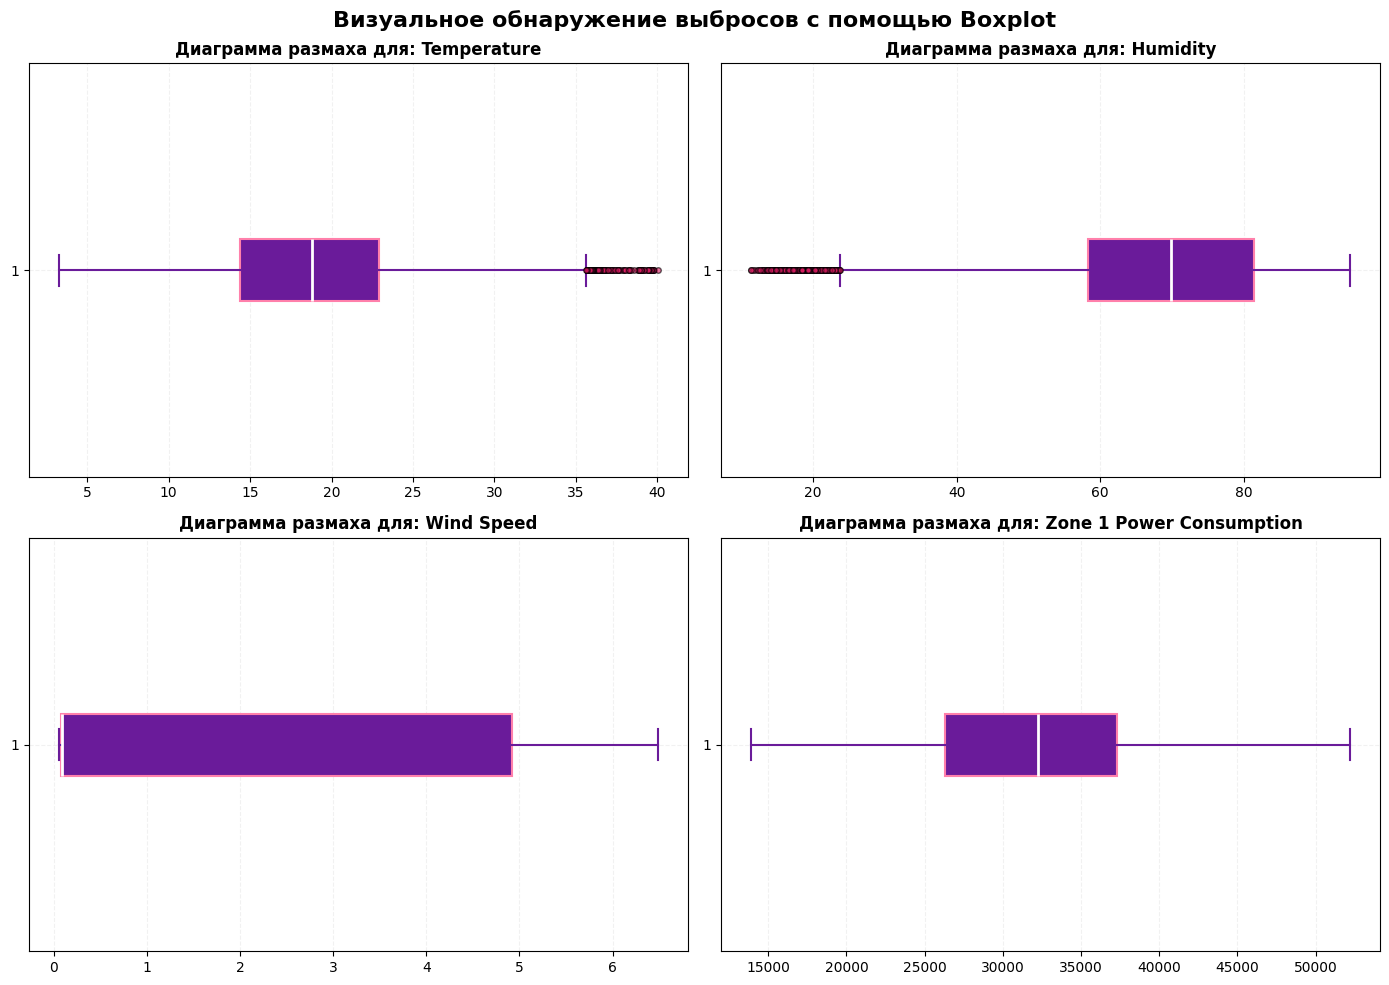

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    "Tetuan_City_cleaned.csv", index_col="DateTime", parse_dates=True)

print("--- 1. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ (%) ---")
missing_percentage = (df.isnull().sum() / len(df)) * 100
for col, val in missing_percentage.items():
    print(f"Канал '{col}': пропусков -> {val:.2f}%")
print("\n" + "=" * 50 + "\n")

print("--- 2. РАСЧЕТ ВЫБРОСОВ ПО ПРАВИЛУ ТРЁХ СИГМ ---")
outliers_summary = {}

for col in df.columns:
    mean_val = df[col].mean()
    std_val = df[col].std()

    lower_bound = mean_val - 3 * std_val
    upper_bound = mean_val + 3 * std_val

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_pct = (outliers_count / len(df)) * 100

    outliers_summary[col] = outliers_count
    print(f"Канал '{col}':")
    print(f"  Границы нормы: от {lower_bound:.2f} до {upper_bound:.2f}")
    print(f"  Выбросов: {outliers_count} шт. ({outliers_pct:.2f}%)")
print("\n" + "=" * 50 + "\n")

selected_cols = [
    "Temperature",
    "Humidity",
    "Wind Speed",
    "Zone 1 Power Consumption",
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    axes[i].boxplot(
        df[col],
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor="#6A1B9A", color="#FF80AB", linewidth=1.5),
        whiskerprops=dict(color="#6A1B9A", linewidth=1.5),
        capprops=dict(color="#6A1B9A", linewidth=1.5),
        medianprops=dict(color="#FFF", linewidth=2),
        flierprops=dict(
            marker="o", markerfacecolor="#D81B60", markersize=4, alpha=0.6
        ),
    )
    axes[i].set_title(
        f"Диаграмма размаха для: {col}", fontsize=12, fontweight="bold"
    )
    axes[i].grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")

plt.suptitle(
    "Визуальное обнаружение выбросов с помощью Boxplot",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

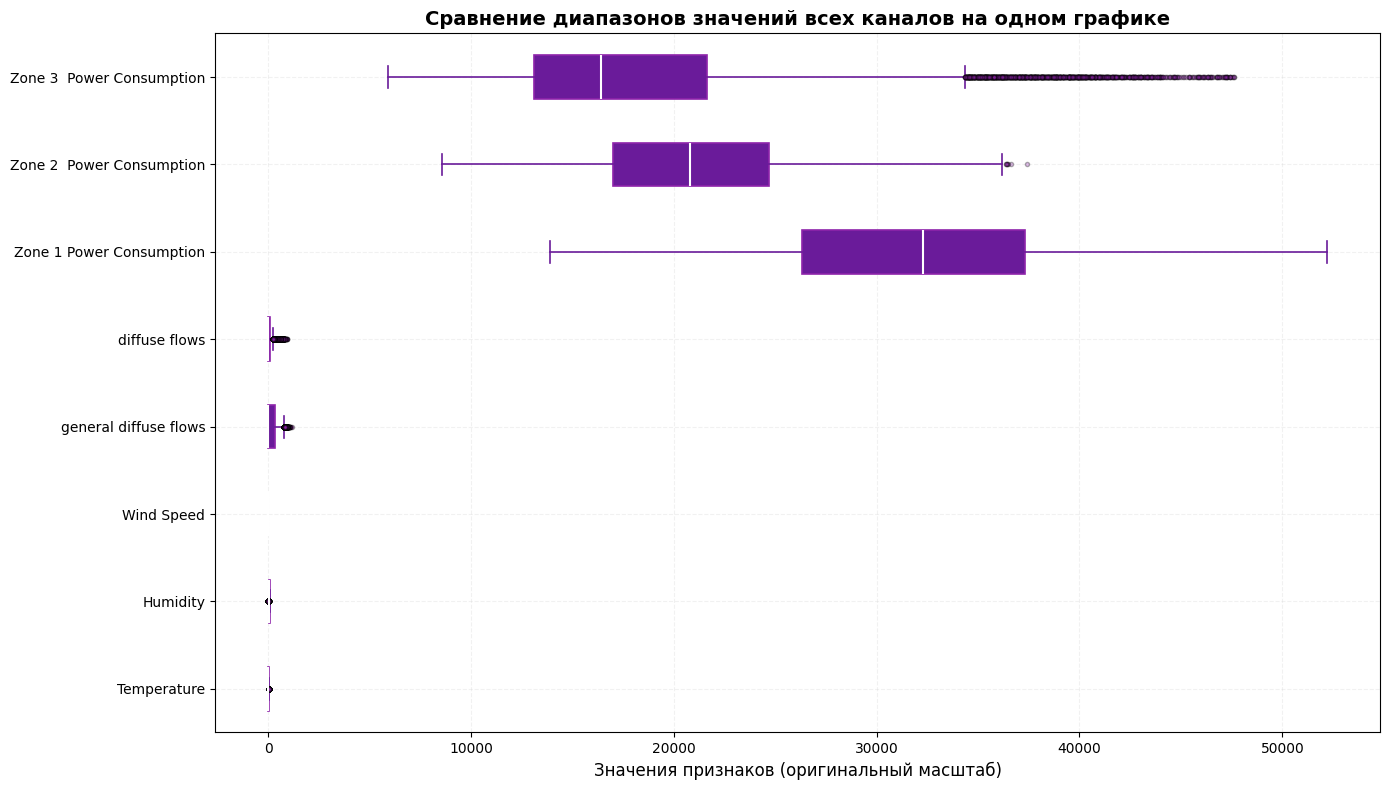

In [7]:
#Сравнение диапазонов

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(
    "Tetuan_City_cleaned.csv", index_col="DateTime", parse_dates=True)

plt.figure(figsize=(14, 8))

bplot = plt.boxplot(
    [df[col] for col in df.columns],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#6A1B9A", color="#8E24AA", linewidth=1.2),
    whiskerprops=dict(color="#6A1B9A", linewidth=1.2),
    capprops=dict(color="#6A1B9A", linewidth=1.2),
    medianprops=dict(color="#FFF", linewidth=1.5),
    flierprops=dict(
        marker="o", markerfacecolor="#8E24AA", markersize=3, alpha=0.3
    ),
)

plt.yticks(range(1, len(df.columns) + 1), df.columns, fontsize=10)
plt.xlabel("Значения признаков (оригинальный масштаб)", fontsize=12)
plt.title(
    "Сравнение диапазонов значений всех каналов на одном графике",
    fontsize=14,
    fontweight="bold",
)
plt.grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")

plt.tight_layout()
plt.show()

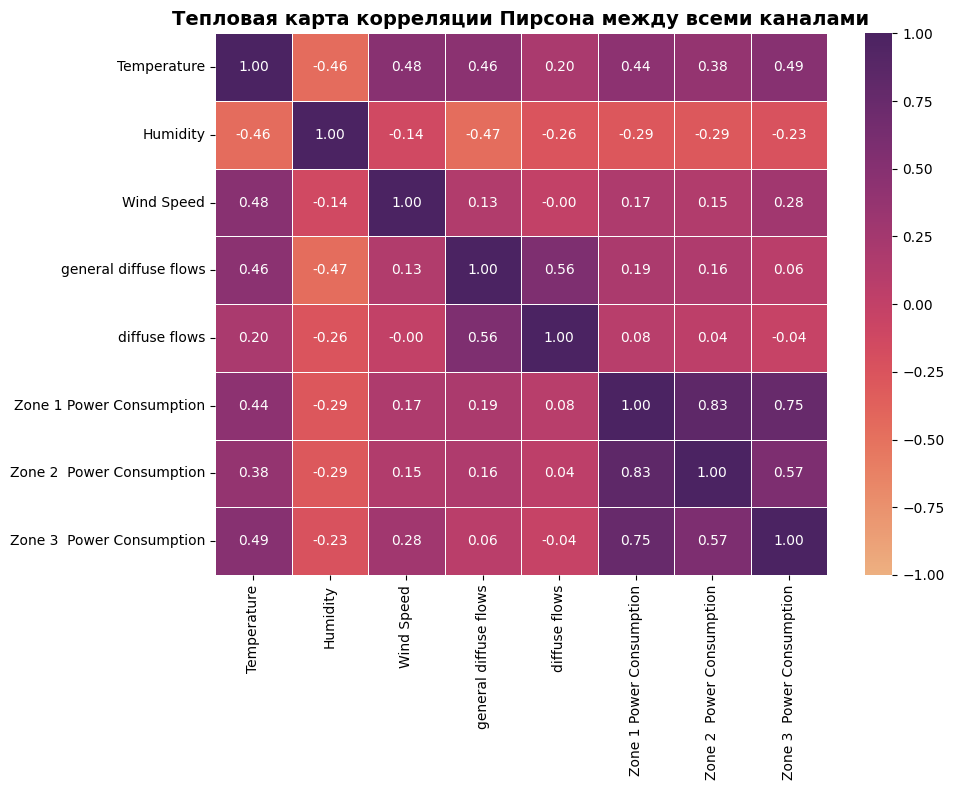

--- Корреляция всех признаков с целевым каналом Zone 1 Power Consumption ---
Zone 1 Power Consumption     1.000000
Zone 2  Power Consumption    0.834519
Zone 3  Power Consumption    0.750733
Temperature                  0.440221
general diffuse flows        0.187965
Wind Speed                   0.167444
diffuse flows                0.080274
Humidity                    -0.287421
Name: Zone 1 Power Consumption, dtype: float64


In [8]:
#Матрица корреляции

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv(
    "Tetuan_City_cleaned.csv", index_col="DateTime", parse_dates=True)

corr_matrix = df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="flare",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title(
    "Тепловая карта корреляции Пирсона между всеми каналами",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print("--- Корреляция всех признаков с целевым каналом Zone 1 Power Consumption ---")
print(corr_matrix["Zone 1 Power Consumption"].sort_values(ascending=False))


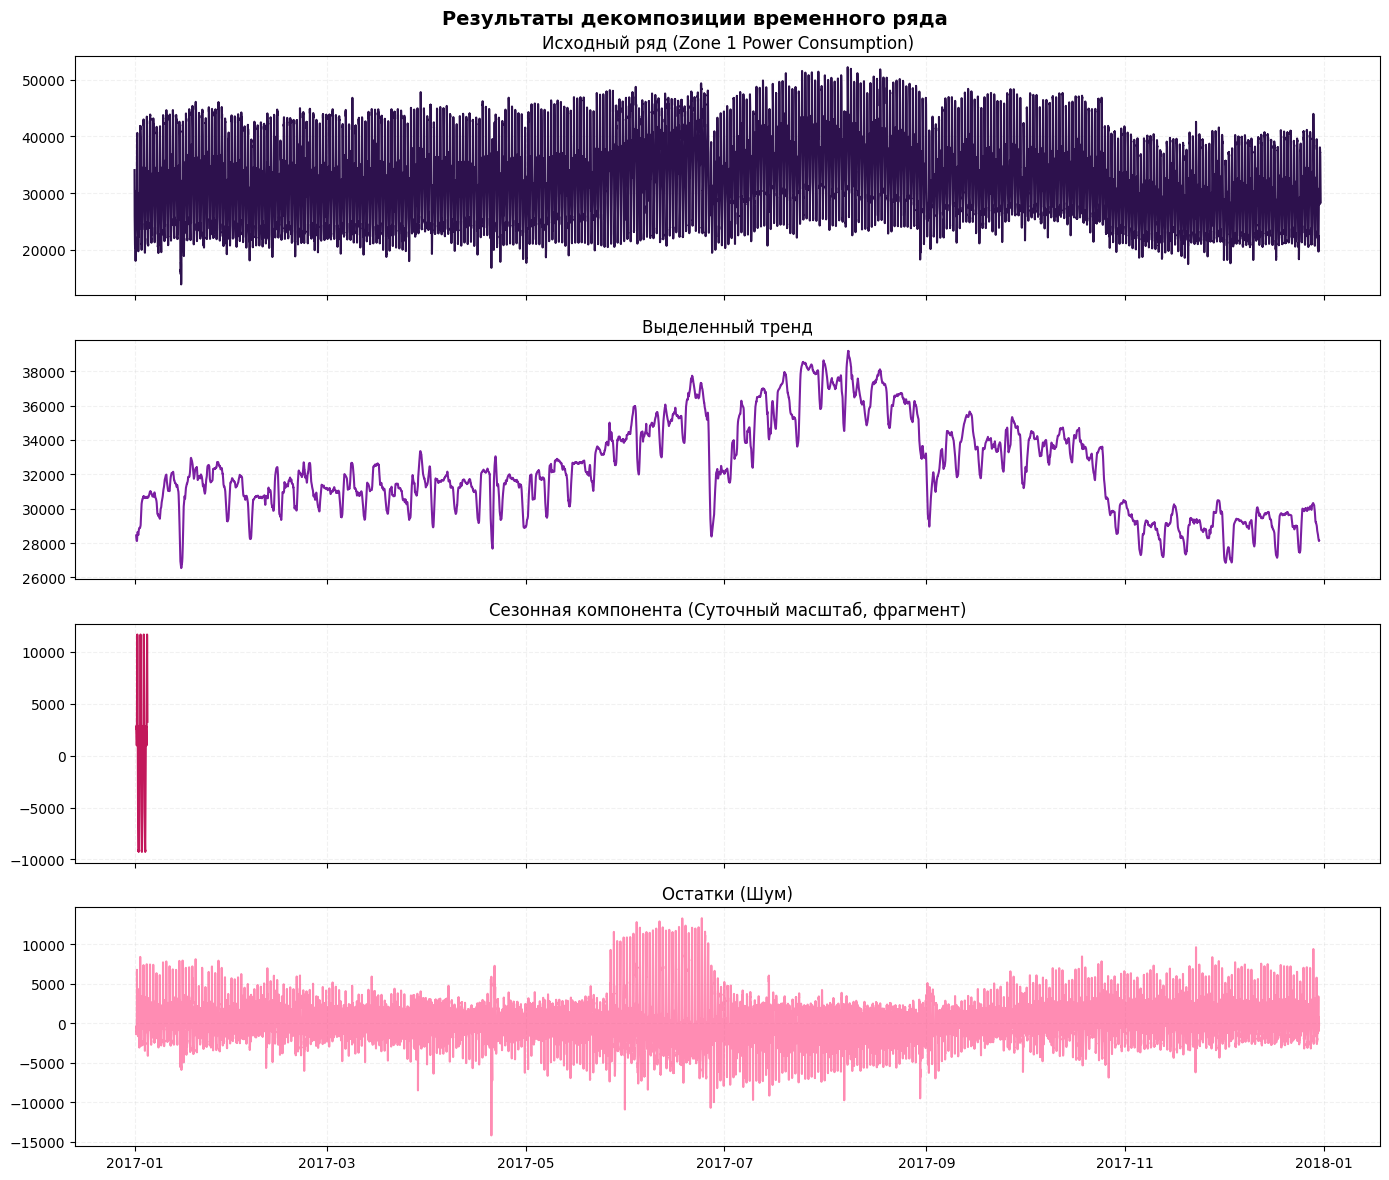

--- РЕЗУЛЬТАТЫ РАСЧЕТА СИГНАЛ/ШУМ ---
Дисперсия полезного сигнала (var_signal): 45392831.50
Дисперсия шума/остатков (var_noise): 5176707.96
Коэффициент SNR: 9.43 дБ




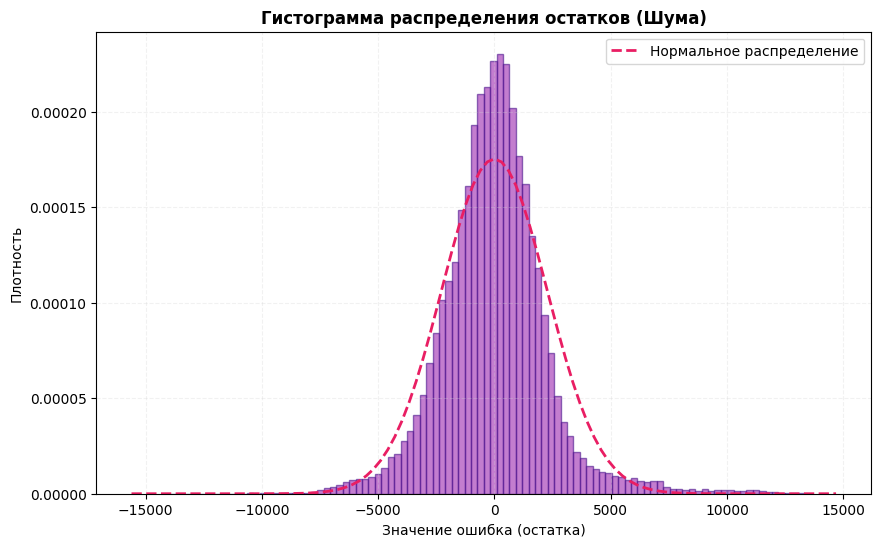

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("Tetuan_City_cleaned.csv", index_col="DateTime", parse_dates=True)

target = df["Zone 1 Power Consumption"]
result = seasonal_decompose(target, model="additive", period=144)

trend = result.trend
seasonal = result.seasonal
resid = result.resid

valid_mask = trend.notna() & resid.notna()
trend_v = trend[valid_mask]
seasonal_v = seasonal[valid_mask]
resid_v = resid[valid_mask]
target_v = target[valid_mask]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(target.index, target, color="#2D114D", label="Исходный ряд")
axes[0].set_title("Исходный ряд (Zone 1 Power Consumption)")
axes[0].grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")

axes[1].plot(trend_v.index, trend_v, color="#7B1FA2", label="Тренд")
axes[1].set_title("Выделенный тренд")
axes[1].grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")

axes[2].plot(
    seasonal_v.index[:500],
    seasonal_v[:500],
    color="#C2185B",
    label="Сезонность",
)
axes[2].set_title("Сезонная компонента (Суточный масштаб, фрагмент)")
axes[2].grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")

axes[3].plot(resid_v.index, resid_v, color="#FF4081", label="Остатки (Шум)", alpha=0.6)
axes[3].set_title("Остатки (Шум)")
axes[3].grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")

plt.suptitle("Результаты декомпозиции временного ряда", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

signal = trend_v + seasonal_v
var_signal = np.var(signal)
var_noise = np.var(resid_v)
snr = 10 * np.log10(var_signal / var_noise)

print("--- РЕЗУЛЬТАТЫ РАСЧЕТА СИГНАЛ/ШУМ ---")
print(f"Дисперсия полезного сигнала (var_signal): {var_signal:.2f}")
print(f"Дисперсия шума/остатков (var_noise): {var_noise:.2f}")
print(f"Коэффициент SNR: {snr:.2f} дБ")
print("\n" + "=" * 50 + "\n")

plt.figure(figsize=(10, 6))

plt.hist(
    resid_v,
    bins=100,
    color="#9C27B0",
    alpha=0.6,
    edgecolor="#4A148C",
    density=True,
)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, np.mean(resid_v), np.std(resid_v))

plt.plot(
    x,
    p,
    color="#E91E63",
    linewidth=2,
    linestyle="--",
    label="Нормальное распределение",
)

plt.title("Гистограмма распределения остатков (Шума)", fontsize=12, fontweight="bold")
plt.xlabel("Значение ошибка (остатка)", fontsize=10)
plt.ylabel("Плотность", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3, color="#D3D3D3")
plt.legend()
plt.show()